## Calibration of Neural Networks

- We will train a shallow CNN
- We will load a even deeper ResNet 

In [229]:
import os
#os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
#os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments'


In [230]:
import torch
import torchvision
import os
from torchvision.datasets import FakeData
from torchvision import transforms
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torch import nn
from torch import optim
import numpy as np
from sklearn import metrics
import random


In [191]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
#torch.use_deterministic_algorithms(True)
#torch.backends.cudnn.deterministic = True


In [192]:
torch.cuda.is_available()


True

In [231]:
ViT_transform = transforms.Compose([
    transforms.Resize(224),  # Resize to match ViT input
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))  # CIFAR-100 stats
])

CNNtransform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

transform = CNNtransform
batch_size = 128

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=8, persistent_workers= True)
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=8, persistent_workers= True)


In [194]:
# A very simple CNN model.

class CNN(nn.Module):
    def __init__(self, dropout=False):
        super().__init__()
        self.dropout=dropout
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(128, 128, kernel_size=3, stride=2, padding=1)  # downsample
        self.conv5 = nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1)  # downsample
        
        self.flatten_dim = 256 * 8 * 8  # assuming input is 32x32
        self.fc1 = nn.Linear(self.flatten_dim, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))   # -> 32x32x32
        x = F.relu(self.conv2(x))   # -> 32x32x64
        x = F.relu(self.conv3(x))   # -> 32x32x128
        x = F.relu(self.conv4(x))   # -> 16x16x128
        x = F.relu(self.conv5(x))   # -> 8x8x256
        x = torch.flatten(x, 1)
        if self.dropout:
            x = F.dropout(F.relu(self.fc1(x)))
            x = F.dropout(F.relu(self.fc2(x)))
        else:
            x = (F.relu(self.fc1(x)))
            x = (F.relu(self.fc2(x)))
        x = self.fc3(x)
        return x


In [195]:
model_name='CNN_dropout'
model = CNN(dropout=True)

In [ ]:
model_name='CNN'
model = CNN(dropout=False)

In [8]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device)

loss =  nn.CrossEntropyLoss()
lr = 0.0001
optimizer = optim.AdamW(model.parameters(), lr=lr)
epochs = 50

In [196]:
load_resnet = False
load = True
if not load_resnet and not load:
    
    for e in range(epochs):
        running_loss = 0
        for it, data in enumerate (trainloader):
            x, y = data
            x, y = x.to(device), y.to(device)
            
            yp = model(x)
            l = loss(yp, y)
            
            optimizer.zero_grad()
            l.backward()
            optimizer.step()
            running_loss += l.item()
            #if it % 100 == 0:
            #    print(it, l.item())
        print(e, running_loss/len(trainloader))
    torch.save(model.state_dict(), f'./cifar10_{model_name}_{epochs}_{optimizer.param_groups[0]["lr"]}.pth')      

In [197]:
# USE THIS CELL TO LOAD THE PRETRAINED MODEL.

if load:
    #model = CNN().to(device)
    #model.load_state_dict(torch.load('./cifar10_CNN2.pth')) #fully trained
    model.load_state_dict(torch.load(f'./cifar10_{model_name}_{epochs}_{optimizer.param_groups[0]["lr"]}.pth'))


if load_resnet:
    model = torch.hub.load("chenyaofo/pytorch-cifar-models", "cifar10_resnet20", pretrained=True)
    model.eval()
    model.cuda()


In [198]:
#here we test the model on test data collecting all predictions
model.cuda()
model.eval()
model.dropout=False
y_gt, y_pred, y_score = [], [],[]
for it, data in enumerate (testloader):
    with torch.no_grad():
        x, y = data
        x, y = x.to(device), y.to(device)
    
        yp = model(x)
    
        y_score.append(yp.max(1).values)
        y_pred.append(yp.argmax(1))
        y_gt.append(y)
        

Accuracy: 0.7093999981880188


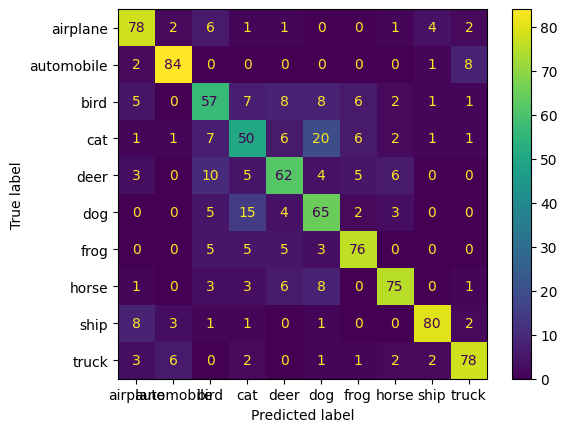

In [199]:
#Here we look at accuracy and confusion matrix
y_pred_t = torch.cat(y_pred)
y_gt_t = torch.cat(y_gt)

y_score_t = torch.cat(y_score)

accuracy = sum(y_pred_t == y_gt_t)/len(y_gt_t)
print(f'Accuracy: {accuracy}')

cm = metrics.confusion_matrix(y_gt_t.cpu(), y_pred_t.cpu())

cmn = cm.astype(np.float32)
cmn/=cmn.sum(1)

cmn = (100*cmn).astype(np.int32)
disp = metrics.ConfusionMatrixDisplay(cmn, display_labels=testset.classes)
disp.plot()
plt.show()


In [200]:
cmn = cm.astype(np.float32)
cmn/=cmn.sum(1)
print(f'Per class accuracy: {np.diag(cmn).mean():.4f}')

Per class accuracy: 0.7094


## Evaluate Temperature Scaling
We define a compute score function to collect all scores given a scoring function.

In [201]:
def max_logit(logit):
    s = logit.max(dim=1)[0] #get the max for each element of the batch
    return s

def max_softmax(logit, T=1.0):
    s = F.softmax(logit/T, 1)
    s = s.max(dim=1)[0] #get the max for each element of the batch
    return s


def compute_scores(data_loader, score_fun):
    scores = []
    with torch.no_grad():
        for data in data_loader:
            x, y = data
            output = model(x.to(device))
            s = score_fun(output)
            scores.append(s)
        scores_t = torch.cat(scores)
        return scores_t







## Compute reliability diagrams for different values of temperature 
We test linearly spaced values of $T \in [0.5, 10]$
For each T:
- We compute the histogram of scores
- We then proceed calculating $\text{acc}(B_m)$ and $\text{conf}(B_m)$ for each bin $B_m$


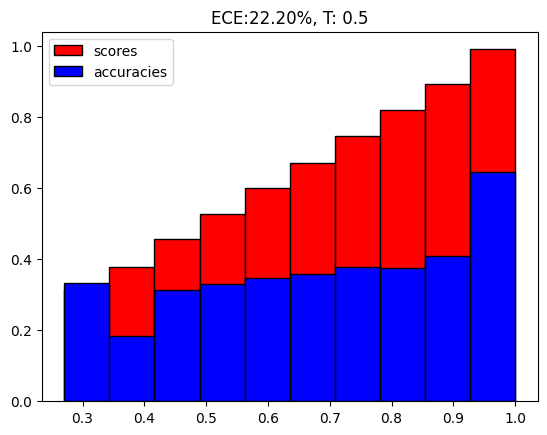

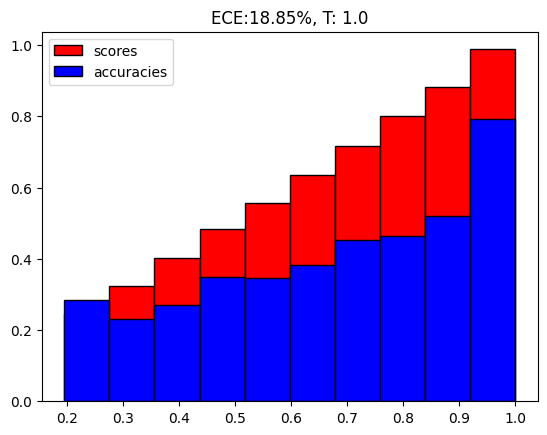

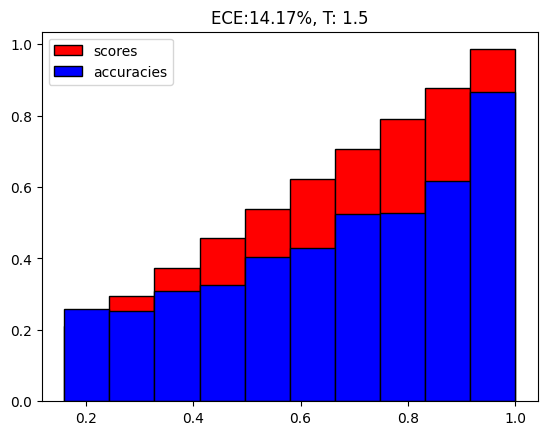

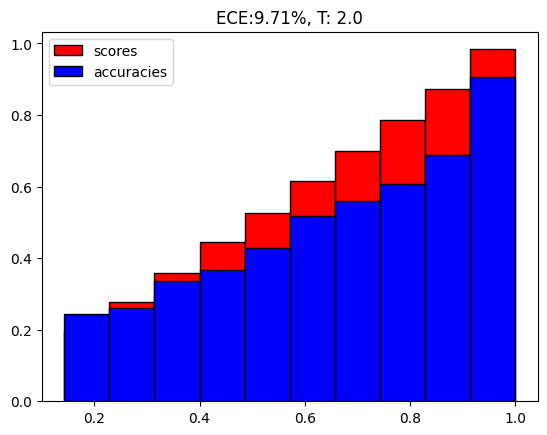

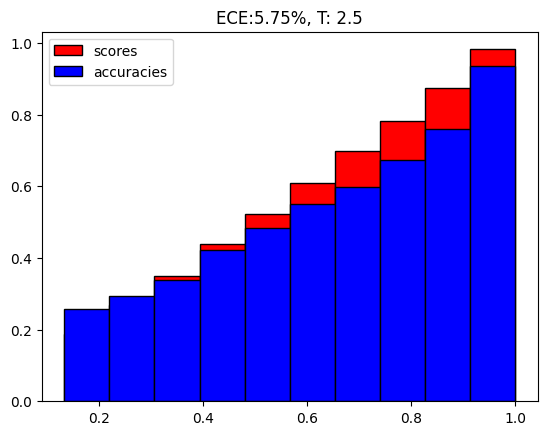

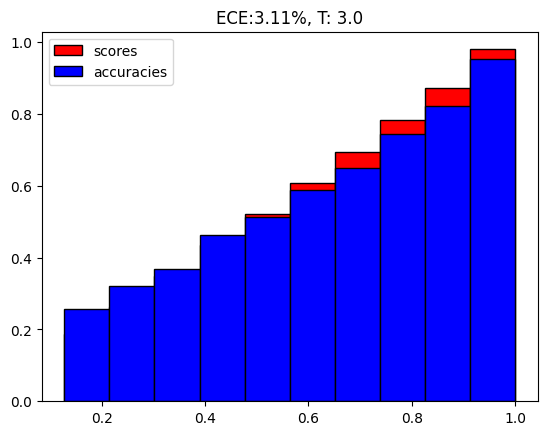

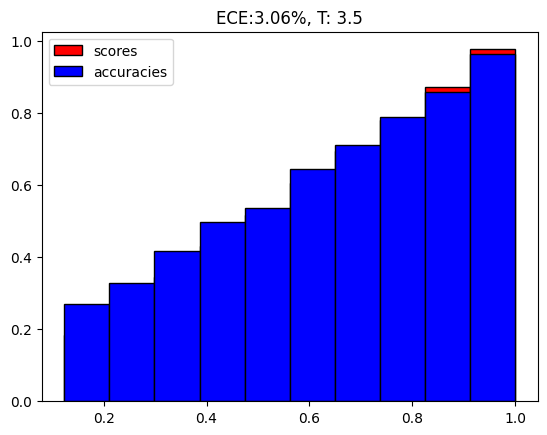

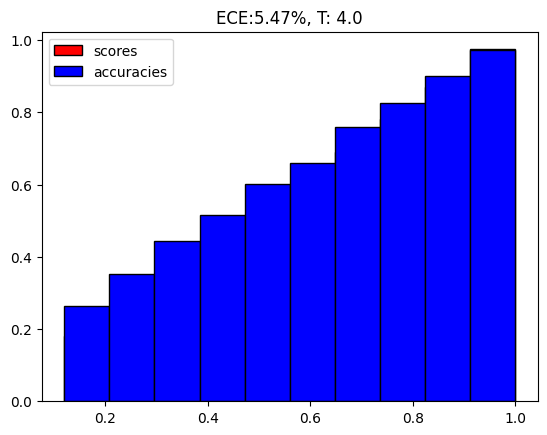

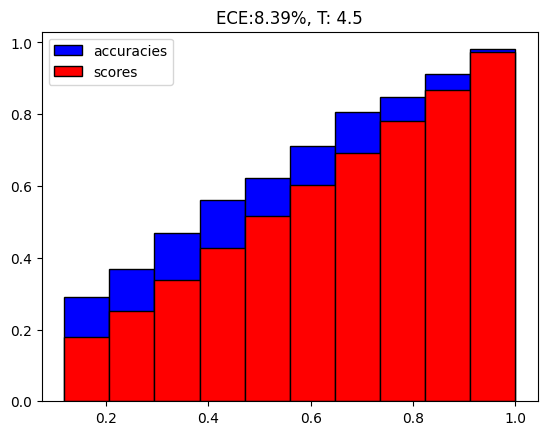

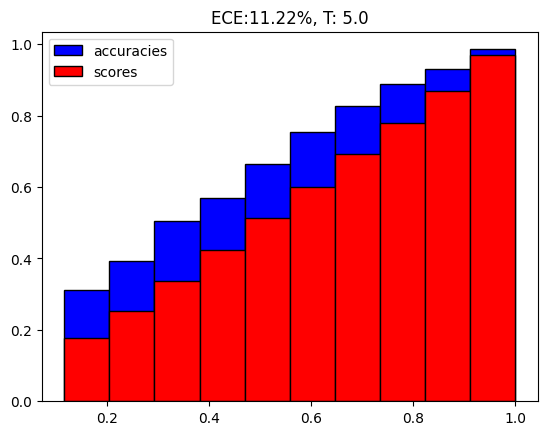

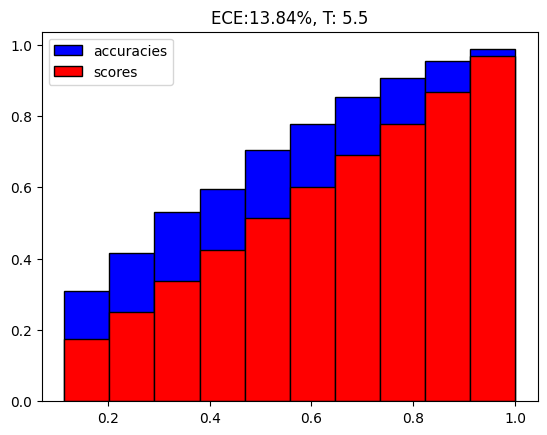

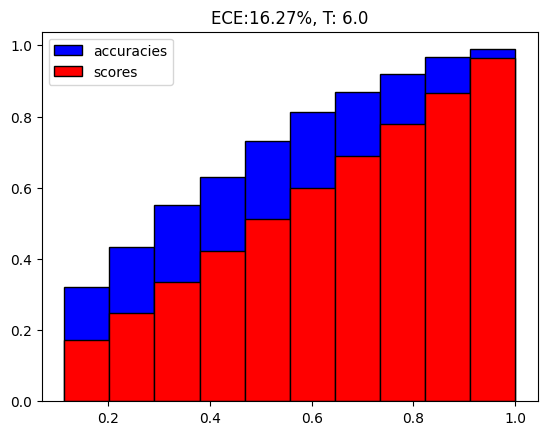

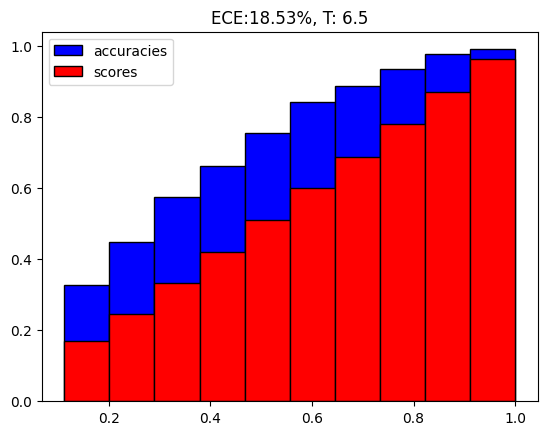

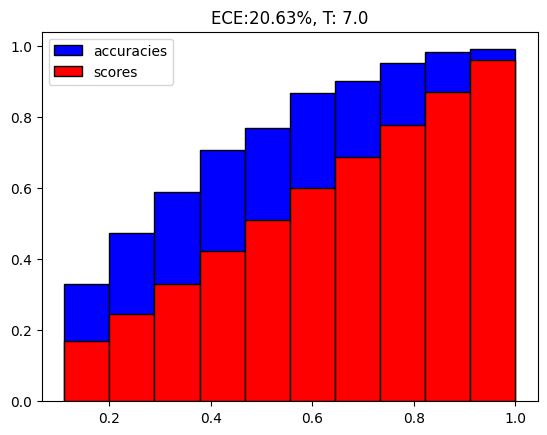

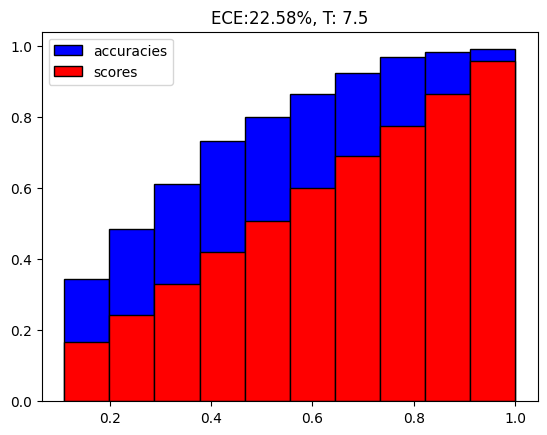

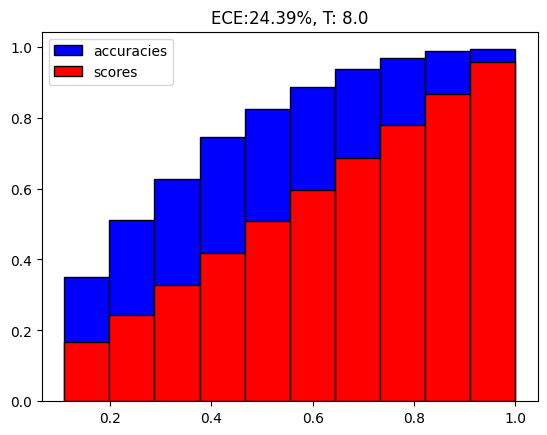

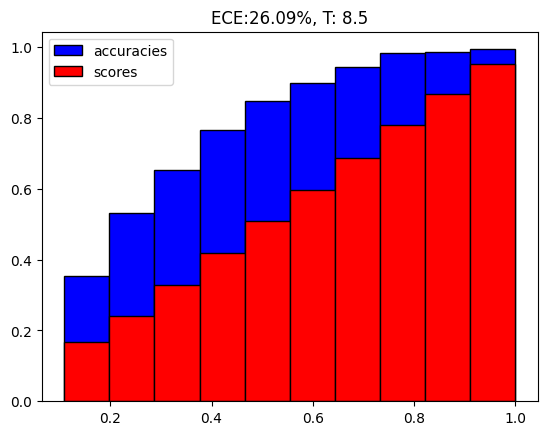

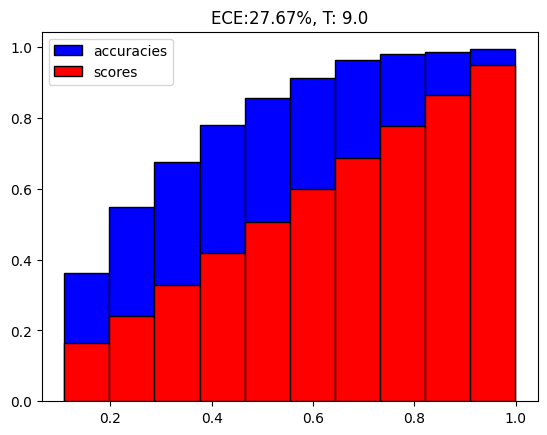

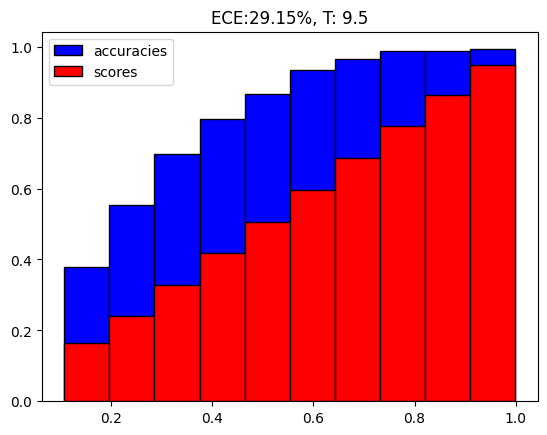

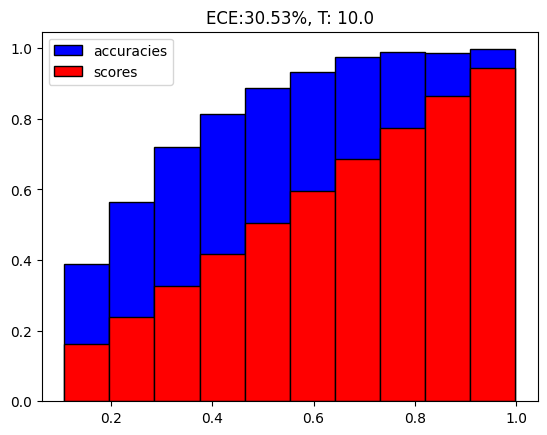

In [202]:
    for temp in np.linspace(0.5, 10, 20):
        scores_test = compute_scores(testloader, lambda l: max_softmax(l, T=temp))
        
        #scores_test = compute_scores(testloader, max_logit)
        b, e = np.histogram(scores_test.cpu(), bins=10)
        scores, accuracies = [],[]
        ece = 0
        for i in range(0,len(e)-1):
            inside_id = np.where((scores_test.cpu() >= e[i]) & (scores_test.cpu() < e[i+1]))[0]
            
            #print(inside_id)
            scores.append(scores_test[inside_id].mean().item())
            if len(inside_id):
                a = sum(y_pred_t[inside_id] == y_gt_t[inside_id])/len(inside_id)
                a = a.item()
            else:
                a = 0
            accuracies.append(a)
        
            ece += ((len(inside_id))/len(scores_test))*abs(a-scores[i])
            
        if max(accuracies)<max(scores):
            plt.bar(e[:-1], scores, width=np.diff(e), edgecolor="black", align="edge",label='scores', facecolor='red')
            plt.title(f'ECE:{100*ece:2.2f}%, T: {temp}')
            plt.legend()
            #plt.show()
            
            plt.bar(e[:-1], accuracies, width=np.diff(e), edgecolor="black", align="edge",label='accuracies', facecolor='blue')
            plt.legend()
            plt.show()
        else:
            
            
            plt.bar(e[:-1], accuracies, width=np.diff(e), edgecolor="black", align="edge",label='accuracies',facecolor='blue')
            plt.legend()

            plt.bar(e[:-1], scores, width=np.diff(e), edgecolor="black", align="edge",label='scores',facecolor='red')
            plt.title(f'ECE:{100*ece:2.2f}%, T: {temp}')
            plt.legend()
            #plt.show()
            
            plt.show()
            


 

## Using sklearn
sklearn can do it for us.... here we compare different temperature scalings in the same plot

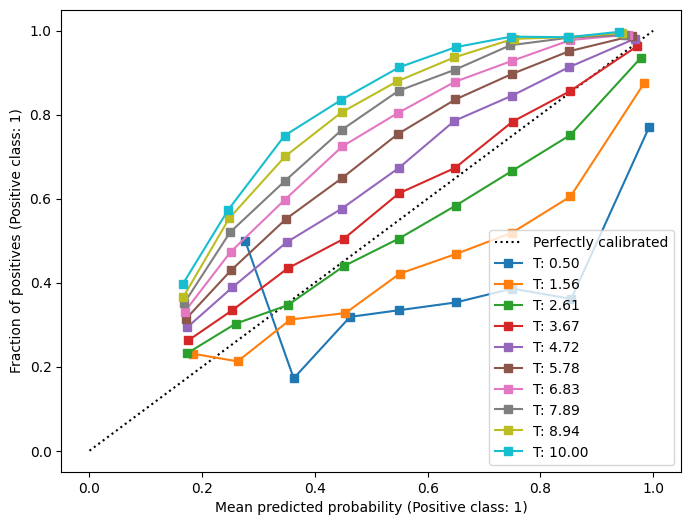

In [203]:

from sklearn.calibration import calibration_curve
from sklearn.calibration import CalibrationDisplay
fig, ax = plt.subplots(figsize=(8, 6))

for temp in np.linspace(0.5, 10, 10):

    scores_test = compute_scores(testloader, lambda l: max_softmax(l, T=temp))
    CalibrationDisplay.from_predictions((y_gt_t==y_pred_t).cpu(), scores_test.cpu(), ax=ax, label=f'T: {temp:2.2f}', n_bins=10)
    #plt.plot(prob_true, prob_pred)

plt.show()



NameError: name 'scores_fake' is not defined

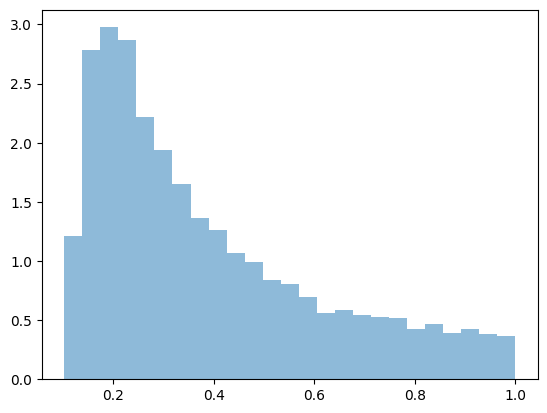

In [24]:
plt.hist(scores_test.cpu(), density=True, alpha=0.5, bins=25,label='test')
plt.hist(scores_fake.cpu(), density=True, alpha=0.5, bins=25,label='fake')
plt.legend()
plt.show()


## Testing if dropout affects inference...

In [228]:
model.dropout=True
preds = []
with torch.no_grad():
    for _ in range(100):
        preds.append(F.softmax(model(x)))
        
mc_preds=torch.stack(preds)    
#pred1.argmax(1), pred2.argmax(1),pred3.argmax(1),pred4.argmax(1), y
#pred1[0].max(), pred2[1].max(), pred3[0].max(), pred4[1].max()
y_pred = mc_preds.mean(0).argmax(1)
std = mc_preds.var(0)
i=1
print(1-std[i][y[i]])
y, y_pred

tensor(0.9489, device='cuda:0')


/tmp/ipykernel_1199037/2103134470.py:5: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  preds.append(F.softmax(model(x)))


(tensor([7, 5, 8, 0, 8, 2, 7, 0, 3, 5, 3, 8, 3, 5, 1, 7], device='cuda:0'),
 tensor([7, 3, 0, 0, 8, 2, 7, 0, 3, 3, 3, 5, 5, 5, 1, 7], device='cuda:0'))

In [221]:

def compute_scores_mc(data_loader, n=100):
    
    with torch.no_grad():
        scores = []
        ypreds=[]
        for data in data_loader:
            x, y = data
            mc_scores=[]
            for _ in range(n):
                output = model(x.to(device))
                mc_scores.append(F.softmax(output))
            
            mc_scores=torch.stack(mc_scores)
            y_pred = mc_scores.mean(0).argmax(1)
            std = mc_scores.std(0)
            #print(std.shape, y_pred.shape)
            y_pred = y_pred.view(-1, 1)
            s = torch.gather(1-std, dim=1, index=y_pred) 
            #scores.append(mc_scores.mean(0).max(1).values)
            scores.append(s)
            ypreds.append(y_pred)
        
            
        return torch.cat(scores), torch.cat(ypreds)

temp=1
scores_test, y_pred_test = compute_scores_mc(testloader)
scores_test.shape, y_pred_test.shape

/tmp/ipykernel_1199037/3509068226.py:11: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  mc_scores.append(F.softmax(output))


(torch.Size([10000, 1]), torch.Size([10000, 1]))

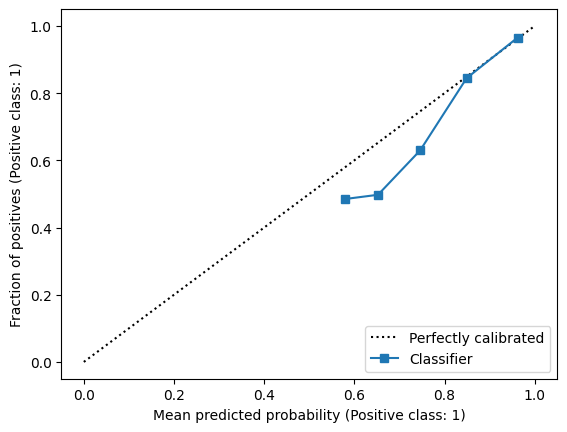

In [222]:
from sklearn.calibration import CalibrationDisplay
CalibrationDisplay.from_predictions( (y_gt_t==y_pred_test.squeeze()).cpu(), scores_test.cpu(), n_bins=10)
#plt.plot()

### Exercise 1.2: Measure your OOD detection performance

There are several metrics used to evaluate OOD detection performance, we will concentrate on two threshold-free approaches: the area under the Receiver Operator Characteristic (ROC) curve for ID classification, and the area under the Precision-Recall curve for *both* ID and OOD scoring. See [the ODIN paper](https://arxiv.org/pdf/1706.02690.pdf) section 4.3 for a description of OOD metrics.

Use the functions in `sklearn.metrics` to produce ROC and PR curves for your OOD detector. Some useful functions:

+ [`sklearn.metric.RocCurveDisplay.from_predictions`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.RocCurveDisplay.html)
+ [`sklearn.metrics.PrecisionRecallDisplay`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.PrecisionRecallDisplay.html)

